

# <center> Lab 3: Image classification using convolutional neural network (CNN)

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

# 1. Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#(x_train, y_train), (x_test, y_test) =mnist.load_data()
np.shape(x_train)

(60000, 28, 28)

In [2]:
d0 = np.shape(x_train[0,0])

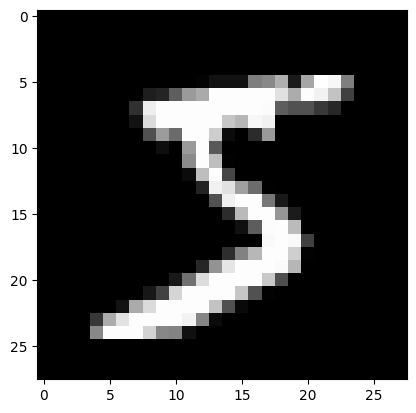

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")

In [4]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Normalize the data
x_train= x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

np.max(x_train)

np.float32(1.0)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# Build a CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
result = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9115 - loss: 0.2866 - val_accuracy: 0.9762 - val_loss: 0.0759
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9650 - loss: 0.1168 - val_accuracy: 0.9850 - val_loss: 0.0512
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9733 - loss: 0.0894 - val_accuracy: 0.9879 - val_loss: 0.0447
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9774 - loss: 0.0756 - val_accuracy: 0.9898 - val_loss: 0.0386
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9793 - loss: 0.0667 - val_accuracy: 0.9890 - val_loss: 0.0393
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9815 - loss: 0.0606 - val_accuracy: 0.9902 - val_loss: 0.0344
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9832 - loss: 0.0554 - val_accuracy: 0.9895 - val_loss: 0.0367
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9850 -

313/313 - 1s - 5ms/step - accuracy: 0.9932 - loss: 0.0228

Test accuracy: 0.9932000041007996


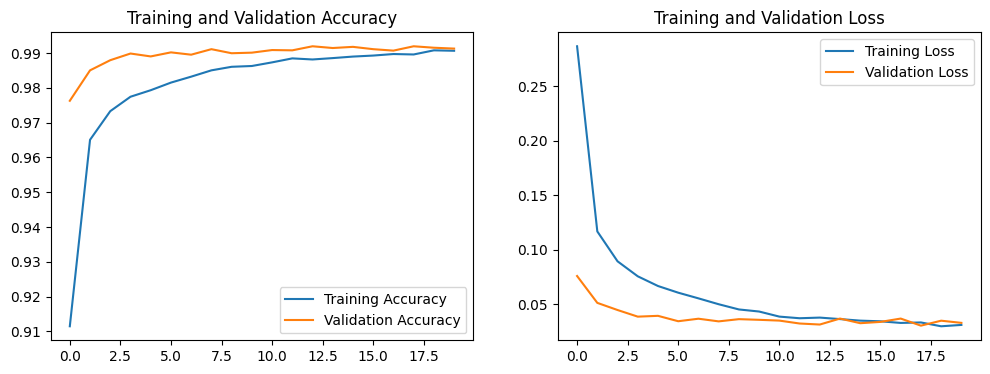

In [8]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(result.history['accuracy'], label='Training Accuracy')
plt.plot(result.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(result.history['loss'], label='Training Loss')
plt.plot(result.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [9]:
#cifar-10
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

# 1. Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#(x_train, y_train), (x_test, y_test) =mnist.load_data()
np.shape(x_train)

(50000, 32, 32, 3)

In [ ]:
d0 = np.shape(x_train[0,0])

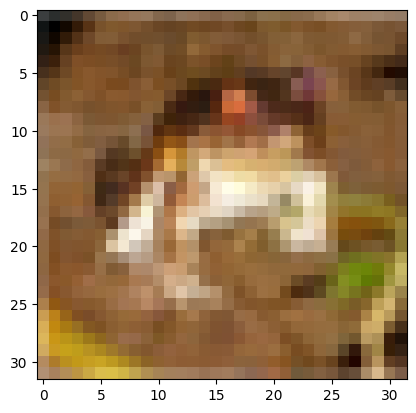

In [10]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Normalize the data
x_train= x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

np.max(x_train)

np.float32(1.0)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# Build a CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
result = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.3638 - loss: 1.7359 - val_accuracy: 0.4928 - val_loss: 1.4220
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4738 - loss: 1.4547 - val_accuracy: 0.5722 - val_loss: 1.2245
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5232 - loss: 1.3282 - val_accuracy: 0.5863 - val_loss: 1.1906
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5517 - loss: 1.2571 - val_accuracy: 0.6038 - val_loss: 1.1109
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5768 - loss: 1.1939 - val_accuracy: 0.6315 - val_loss: 1.0397
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5900 - loss: 1.1534 - val_accuracy: 0.6452 - val_loss: 1.0255
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6073 - loss: 1.1072 - val_accuracy: 0.6624 - val_loss: 0.9493
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.6187 -

313/313 - 2s - 6ms/step - accuracy: 0.7167 - loss: 0.8188

Test accuracy: 0.71670001745224


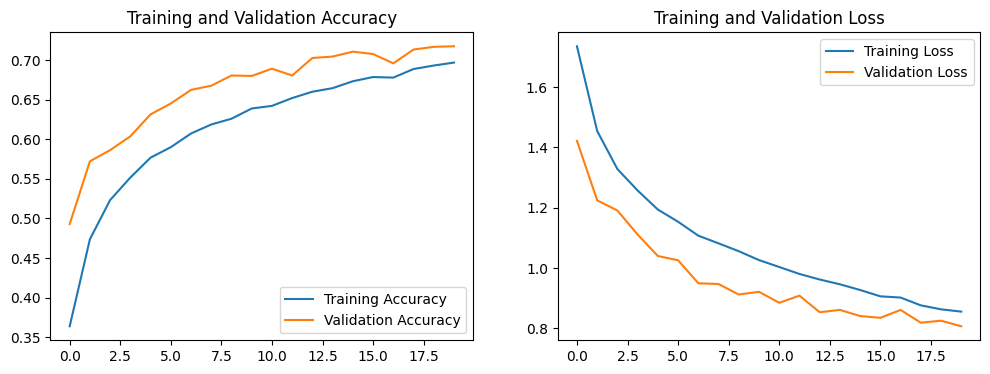

In [14]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(result.history['accuracy'], label='Training Accuracy')
plt.plot(result.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(result.history['loss'], label='Training Loss')
plt.plot(result.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## Example of image classification model using CNN:

The following code does the following:

Loads the CIFAR-10 dataset. Filters out images and labels for birds, cats, and dogs from the original dataset. Remaps the labels for birds, cats, and dogs from their original CIFAR-10 labels to 0, 1, and 2 respectively. Splits the filtered training dataset into a final training, a validation, and testing sets. Prints the shapes of the final training, validation, and test datasets.

CIFAR-10 is a dataset containing 60,000 color images of resolution 32x32 pixels in 10 classes, with 6,000 images per class. The classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

By filtering for birds, cats, and dogs, you're effectively reducing the dataset to 18,000 images (6,000 for each of the three classes). We split 4000 images/class for the training, 1,000 images/class for validation, and 1,000 images/class for testing.

After remapping the labels, the new labels are:

Bird: 0   Cat: 1    Dog: 2


The printed shapes will give you an idea of the dimensions and size of the datasets:

x_train_final.shape: This should output (12000, 32, 32, 3), which indicates 12,000 images for the 3 classes, each of size 32x32 pixels with 3 color channels (RGB).

y_train_final.shape: This should output (12000, 1), indicating there are 12,000 labels corresponding to the 12,000 training images.

Similarly, for the validation data we have:
x_val.shape: (3000, 32, 32, 3) y_val.shape: (3000, 1)

And for the test data:
x_test_filtered.shape: (3000, 32, 32, 3) y_test_filtered.shape: (3000, 1)

This organized data is now ready for training a neural network model.


In [15]:
#with mnist data
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

# 1. Load mnist data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Filter out birds, cats, and dogs from training and test sets
train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]

x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

# Convert labels: bird (2) -> 0, cat (3) -> 1, dog (5) -> 2 for easier processing later
label_map = {2: 0, 3: 1, 5: 2}

y_train_filtered = np.vectorize(label_map.get)(y_train_filtered) # [1,0,0][0,1,0][0,0,1]
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

# 3. Split filtered training data into final training and validation sets
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

print("Training data shapes:")
print(x_train_final.shape)
print(y_train_final.shape)

print("\nValidation data shapes:")
print(x_val.shape)
print(y_val.shape)

print("\nTest data shapes:")
print(x_test_filtered.shape)
print(y_test_filtered.shape)

Training data shapes:
(14008, 28, 28)
(14008,)

Validation data shapes:
(3502, 28, 28)
(3502,)

Test data shapes:
(2934, 28, 28)
(2934,)


### Plot few images from each class for verification

Creating a convolutional neural network (CNN) to classify images as dogs, cats, or birds requires a few key steps:

Data Collection: You'll need labeled images of dogs, cats, and birds. There are several public datasets like CIFAR-10 or Kaggle's Dogs vs. Cats competition dataset.

Data Preprocessing: Normalize the images, resize them to a consistent size, and split them into training, validation, and test sets.

Model Building: Design the CNN architecture.

Training: Train the model on your training set.

Evaluation: Evaluate the model's performance on the validation and test sets.

Below is a simple CNN using TensorFlow and Keras for this classification problem:

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9578 - loss: 0.1150 - val_accuracy: 0.9866 - val_loss: 0.0426
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9853 - loss: 0.0422 - val_accuracy: 0.9926 - val_loss: 0.0257
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9934 - val_loss: 0.0221
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accuracy: 0.9940 - val_loss: 0.0219
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9924 - loss: 0.0240 - val_accuracy: 0.9937 - val_loss: 0.0219
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9929 - val_loss: 0.0225
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9943 - loss: 0.0168 - val_accuracy: 0.9943 - val_loss: 0.0215
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accu

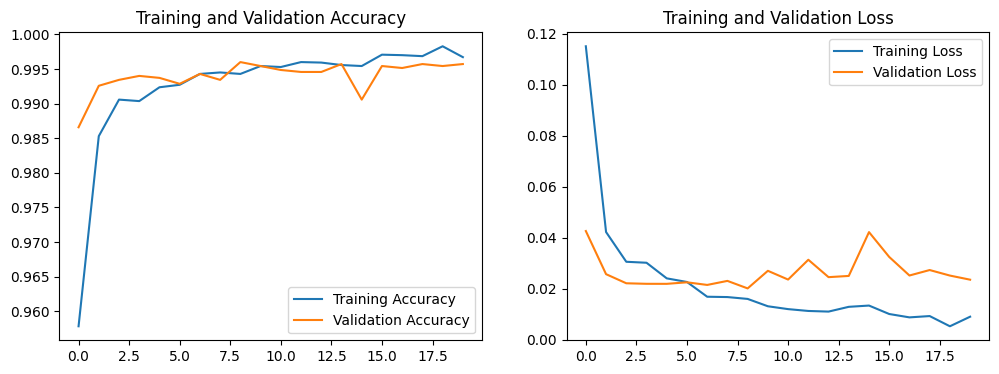

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
# Reverted back to MaxPooling2D in the imports
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.model_selection import train_test_split

# Load MNIST data and preprocess
(x_train, y_train), (x_test, y_test) = mnist.load_data()

train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]
x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

label_map = {2: 0, 3: 1, 5: 2}
y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

# Normalize the data
x_train_final = x_train_final.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0

# Expand dimensions to include the single grayscale channel
x_train_final = np.expand_dims(x_train_final, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)
x_test_filtered = np.expand_dims(x_test_filtered, axis=-1)

# Build the CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),

    # CHANGED: activation to 'elu', KEPT: MaxPooling2D
    Conv2D(32, (3, 3), activation='elu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # CHANGED: activation to 'elu', KEPT: MaxPooling2D
    Conv2D(64, (3, 3), activation='elu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    
    # CHANGED: activation to 'elu'
    Dense(128, activation='elu'),
    Dropout(0.5),
    
    # Softmax must remain for multi-class probability output
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_final, y_train_final, epochs=20, validation_data=(x_val, y_val))

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test_filtered, y_test_filtered, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Load a few images from the test set
num_images = 10
random_indices = np.random.choice(len(x_test_filtered), size=num_images, replace=False)
sample_images = x_test_filtered[random_indices]
sample_labels = y_test_filtered[random_indices].squeeze()  # squeeze labels to get 1D array

# Get model predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# Map our label indices back to actual class names
label_names = {0: 'Bird', 1: 'Cat', 2: 'Dog'}

# Plot the images alongside predictions
# Plot the images alongside predictions
plt.figure(figsize=(5 * num_images, 5 * num_images))
for i, (image, true_label, pred_label) in enumerate(zip(sample_images, sample_labels, predicted_labels)):
    ax = plt.subplot(num_images, 1, i + 1)
    ax.imshow(image)
    ax.set_title(f"True: {label_names[true_label]}, Pred: {label_names[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
#with cifar-10 data
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# 1. Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Filter out birds, cats, and dogs from training and test sets
train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]

x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

# Convert labels: bird (2) -> 0, cat (3) -> 1, dog (5) -> 2 for easier processing later
label_map = {2: 0, 3: 1, 5: 2}

y_train_filtered = np.vectorize(label_map.get)(y_train_filtered) # [1,0,0][0,1,0][0,0,1]
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

# 3. Split filtered training data into final training and validation sets
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

print("Training data shapes:")
print(x_train_final.shape)
print(y_train_final.shape)

print("\nValidation data shapes:")
print(x_val.shape)
print(y_val.shape)

print("\nTest data shapes:")
print(x_test_filtered.shape)
print(y_test_filtered.shape)

Training data shapes:
(12000, 32, 32, 3)
(12000, 1)

Validation data shapes:
(3000, 32, 32, 3)
(3000, 1)

Test data shapes:
(3000, 32, 32, 3)
(3000, 1)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4667 - loss: 1.0276 - val_accuracy: 0.5273 - val_loss: 0.9363
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5596 - loss: 0.9268 - val_accuracy: 0.6087 - val_loss: 0.8755
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6077 - loss: 0.8588 - val_accuracy: 0.6403 - val_loss: 0.8007
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6314 - loss: 0.8112 - val_accuracy: 0.6513 - val_loss: 0.7879
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6528 - loss: 0.7761 - val_accuracy: 0.6720 - val_loss: 0.7403
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6708 - loss: 0.7448 - val_accuracy: 0.6833 - val_loss: 0.7164
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6847 - loss: 0.7234 - val_accuracy: 0.6877 - val_loss: 0.7099
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6999 - loss: 0.6944 - val_accu

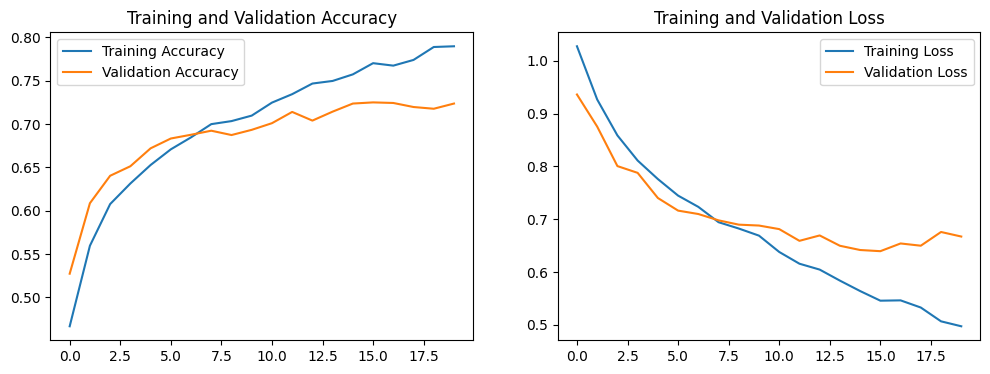

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.model_selection import train_test_split

# Load CIFAR-10 data and preprocess
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

train_indices = np.where((y_train == 2) | (y_train == 3) | (y_train == 5))[0]
test_indices = np.where((y_test == 2) | (y_test == 3) | (y_test == 5))[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]
x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

label_map = {2: 0, 3: 1, 5: 2}
y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

x_train_final, x_val, y_train_final, y_val = train_test_split(x_train_filtered, y_train_filtered, test_size=0.2, random_state=42, stratify=y_train_filtered)

# Normalize the data
x_train_final = x_train_final.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0

# Build the CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train_final, y_train_final, epochs=20, validation_data=(x_val, y_val))

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test_filtered, y_test_filtered, verbose=2)
print("\nTest accuracy:", test_acc)

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


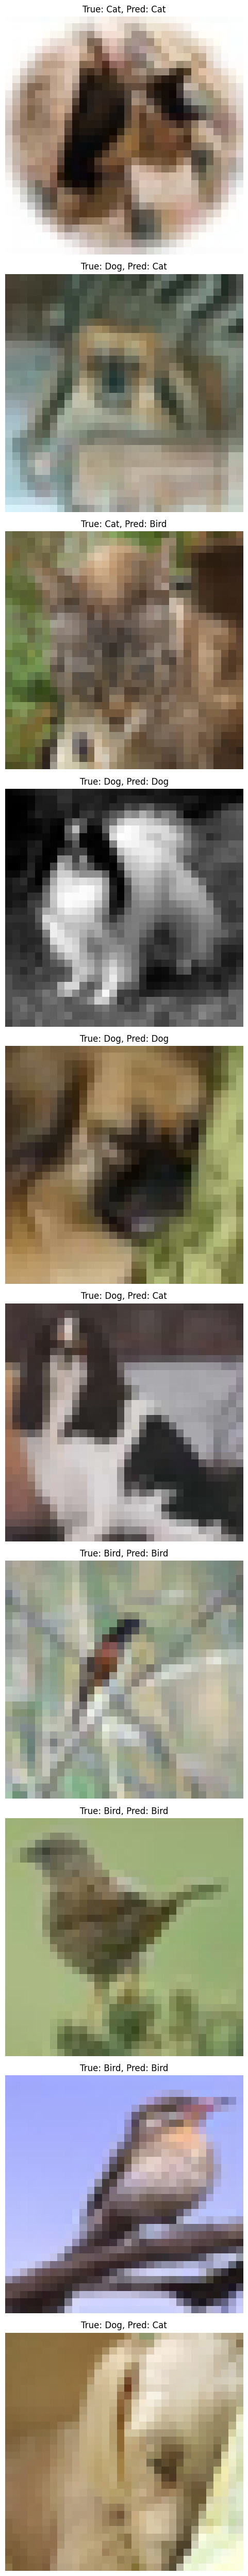

In [19]:
# Load a few images from the test set
num_images = 10
random_indices = np.random.choice(len(x_test_filtered), size=num_images, replace=False)
sample_images = x_test_filtered[random_indices]
sample_labels = y_test_filtered[random_indices].squeeze()  # squeeze labels to get 1D array

# Get model predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# Map our label indices back to actual class names
label_names = {0: 'Bird', 1: 'Cat', 2: 'Dog'}

# Plot the images alongside predictions
# Plot the images alongside predictions
plt.figure(figsize=(5 * num_images, 5 * num_images))
for i, (image, true_label, pred_label) in enumerate(zip(sample_images, sample_labels, predicted_labels)):
    ax = plt.subplot(num_images, 1, i + 1)
    ax.imshow(image)
    ax.set_title(f"True: {label_names[true_label]}, Pred: {label_names[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Lab tasks: Creating a four-class classifier using CNN to categorize transportation vehicles
In this part,
- You need to develop a CNN model to classify four types of transportation vehicles, namely airplane, automobile, ship, and truck.
- Use images in CIFAR-10 dataset to finish the tasks.

Please do:
- Print the necessary values, including but not limited to shapes and labels, to defence your work.
- Keep your code and results tidy and readable for signing off.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, Dropout, BatchNormalization, ReLU

**Task 1:** Dataset preparation (0.5%)
- Load CIFAR-10 dataset and filter out the interested classes.
- Remap the labels.

In [21]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [22]:
# Filter airplane, automobile, ship, and truck

train_indices = np.where(
    (y_train == 0) | (y_train == 1) | (y_train == 8) | (y_train == 9)
)[0]

test_indices = np.where(
    (y_test == 0) | (y_test == 1) | (y_test == 8) | (y_test == 9)
)[0]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]

x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

In [23]:
# Remap labels: airplane to 0, automobile to 1, ship to 2, truck to 3

label_map = {0: 0, 1: 1, 8: 2, 9: 3}

y_train_filtered = np.vectorize(label_map.get)(y_train_filtered)
y_test_filtered = np.vectorize(label_map.get)(y_test_filtered)

In [24]:
# Verify the filtered dataset and remapped labels

print("Training data shape:", x_train_filtered.shape)
print("Training labels shape:", y_train_filtered.shape)

print("Test data shape:", x_test_filtered.shape)
print("Test labels shape:", y_test_filtered.shape)

print("Unique training labels:", np.unique(y_train_filtered))
print("Unique test labels:", np.unique(y_test_filtered))

Training data shape: (20000, 32, 32, 3)
Training labels shape: (20000, 1)
Test data shape: (4000, 32, 32, 3)
Test labels shape: (4000, 1)
Unique training labels: [0 1 2 3]
Unique test labels: [0 1 2 3]


**Task 2:** Data splitting and preprocessing (0.8)

- Split the original training set into training and validation sets with a ratio of 80-20.
- Convert the values into 32-bit floats and apply max-min normalization.

In [25]:
# Task 2: Split the filtered training data into training and validation sets

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_filtered,
    y_train_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_train_filtered
)

In [26]:
# Convert values to float32 and apply min-max normalization

x_train_final = x_train_final.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0

In [27]:
# Verify the shapes, data type, and normalized range

print("Training data shape:", x_train_final.shape)
print("Training labels shape:", y_train_final.shape)

print("Validation data shape:", x_val.shape)
print("Validation labels shape:", y_val.shape)

print("Test data shape:", x_test_filtered.shape)
print("Test labels shape:", y_test_filtered.shape)

print("\nData type:", x_train_final.dtype)
print("Minimum pixel value:", np.min(x_train_final))
print("Maximum pixel value:", np.max(x_train_final))

Training data shape: (16000, 32, 32, 3)
Training labels shape: (16000, 1)
Validation data shape: (4000, 32, 32, 3)
Validation labels shape: (4000, 1)
Test data shape: (4000, 32, 32, 3)
Test labels shape: (4000, 1)

Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


**Task 3:** Build and train a CNN model (1.5%)
- Build a CNN model.
- Use "for" loops to adjust hyperparameters and train the model. Based on the accuracy and loss curves, determine which combination of hyperparameters yields the best results.
- Use the combination of hyperparameters to train the model with the highest validation accuracy.

In [28]:
# TODO: Build a CNN model.
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_final,
    y_train_final,
    epochs=20,
    validation_data=(x_val, y_val)
)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(
    x_test_filtered,
    y_test_filtered,
    verbose=2
)

print("\nTest accuracy:", test_acc)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.5073 - loss: 1.0893 - val_accuracy: 0.6305 - val_loss: 0.9038
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6528 - loss: 0.8507 - val_accuracy: 0.7225 - val_loss: 0.7076
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7107 - loss: 0.7316 - val_accuracy: 0.7703 - val_loss: 0.6037
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7519 - loss: 0.6466 - val_accuracy: 0.8060 - val_loss: 0.5172
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7754 - loss: 0.5900 - val_accuracy: 0.8230 - val_loss: 0.4694
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7965 - loss: 0.5416 - val_accuracy: 0.8240 - val_loss: 0.4677
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8095 - loss: 0.5082 - val_accuracy: 0.8340 - val_loss: 0.4415
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8226 - loss: 0.4833 - 

In [29]:
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.35),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_final,
    y_train_final,
    epochs=20,
    validation_data=(x_val, y_val)
)

test_loss, test_acc = model.evaluate(
    x_test_filtered,
    y_test_filtered,
    verbose=2
)

print("\nTest accuracy:", test_acc)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 83ms/step - accuracy: 0.4947 - loss: 1.1049 - val_accuracy: 0.6522 - val_loss: 0.8380
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step - accuracy: 0.6660 - loss: 0.8195 - val_accuracy: 0.7520 - val_loss: 0.6461
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.7483 - loss: 0.6457 - val_accuracy: 0.8075 - val_loss: 0.5162
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.7847 - loss: 0.5607 - val_accuracy: 0.8175 - val_loss: 0.4785
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.8119 - loss: 0.5060 - val_accuracy: 0.8455 - val_loss: 0.4073
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.8294 - loss: 0.4634 - val_accuracy: 0.8480 - val_loss: 0.4102
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.8389 - loss: 0.4317 - val_accuracy: 0.8547 - val_loss: 0.4010
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 105ms/step - accuracy: 0.8523 - loss: 0.3985 

In [30]:
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.20),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.20),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.40),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    validation_data=(x_val, y_val)
)

test_loss, test_acc = model.evaluate(
    x_test_filtered,
    y_test_filtered,
    verbose=2
)

print("\nTest accuracy:", test_acc)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/step - accuracy: 0.5236 - loss: 1.0624 - val_accuracy: 0.5997 - val_loss: 0.9511
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.6946 - loss: 0.7638 - val_accuracy: 0.7847 - val_loss: 0.5761
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.7763 - loss: 0.5918 - val_accuracy: 0.8067 - val_loss: 0.5332
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.8198 - loss: 0.4974 - val_accuracy: 0.8443 - val_loss: 0.4166
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 93ms/step - accuracy: 0.8389 - loss: 0.4341 - val_accuracy: 0.8620 - val_loss: 0.3676
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 85ms/step - accuracy: 0.8604 - loss: 0.3855 - val_accuracy: 0.8643 - val_loss: 0.3648
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.8687 - loss: 0.3553 - val_accuracy: 0.8727 - val_loss: 0.3753
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8776 - loss: 0.3276 

In [31]:
# TODO: Answer the question
print("Q: What are the hyperparameters in your case?")
print("A: The hyperparameters are:")
print("   Filters = 64, 128, 256")
print("   Dropout rates = 0.20, 0.20, 0.30, 0.40")
print("   Dense units = 128")
print("   Epochs = 30")
print("   Optimizer = Adam")
print("   Batch size = 32 (default)")

Q: What are the hyperparameters in your case?
A: The hyperparameters are:
   Filters = 64, 128, 256
   Dropout rates = 0.20, 0.20, 0.30, 0.40
   Dense units = 128
   Epochs = 30
   Optimizer = Adam
   Batch size = 32 (default)


**Task 4:** Testing the model (1.5%)
- Evaluate your model on the entire testing set.
- Repeat Task 3 until you get a test accuracy higher than 90%. If you are confident on the hyperparameters but the testing accuracy is not satisfactory, that means the model structure needs to be optimized.
- Randomly select 10 images from the testing set, predict their labels, and compare the predicted labels to the true labels.

In [32]:
#TODO: Evaluate your model on the entire testing set.
test_loss, test_acc = model.evaluate(
    x_test_filtered,
    y_test_filtered,
    verbose=2
)

print("\nTest accuracy:", test_acc)

125/125 - 4s - 35ms/step - accuracy: 0.8898 - loss: 0.4051

Test accuracy: 0.8897500038146973


In [33]:
# TODO: Repeat Task 3 until you get a test accuracy higher than 90%.
if test_acc < 0.9:
    print("\nYour targeted test accuracy is 90%. Please achieve this target by adjusting your model in Task 3!")
else:
    print("\nYou have achieved the goal of reaching a 90% test accuracy!")


Your targeted test accuracy is 90%. Please achieve this target by adjusting your model in Task 3!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step


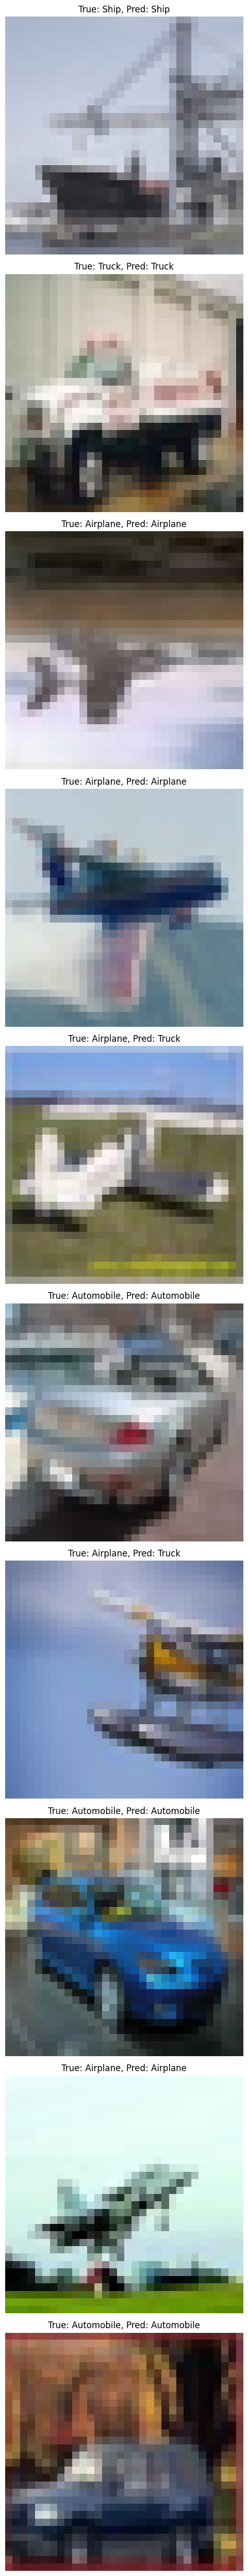

In [34]:
# TODO: Randomly select 10 images from the testing set, predict their labels, and compare the predicted labels to the true labels.# TODO: Evaluate your model on the entire testing set.


# Load a few images from the test set
num_images = 10
random_indices = np.random.choice(
    len(x_test_filtered),
    size=num_images,
    replace=False
)

sample_images = x_test_filtered[random_indices]
sample_labels = y_test_filtered[random_indices].squeeze()  # squeeze labels to get 1D array

# Get model predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# Map our label indices back to actual class names
label_names = {
    0: 'Airplane',
    1: 'Automobile',
    2: 'Ship',
    3: 'Truck'
}

# Plot the images alongside predictions
plt.figure(figsize=(5 * num_images, 5 * num_images))

for i, (image, true_label, pred_label) in enumerate(
    zip(sample_images, sample_labels, predicted_labels)
):
    ax = plt.subplot(num_images, 1, i + 1)
    ax.imshow(image)
    ax.set_title(
        f"True: {label_names[true_label]}, Pred: {label_names[pred_label]}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()